## **Parte B: Análise de Séries Temporais - Inadimplência no Brasil**
Esta seção foca na evolução histórica da inadimplência e sua correlação com indicadores macroeconômicos (SELIC e IPCA).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

def consulta_bcb(codigo_serie):
    url = f'https://api.bcb.gov.br/dados/serie/bcdata.sgs.{codigo_serie}/dados?formato=json'
    headers = {'User-Agent': 'Mozilla/5.0'}
    try:
        response = requests.get(url, headers=headers)
        if response.status_code != 200:
            return pd.DataFrame()
        data_json = response.json()

        if not isinstance(data_json, list) or len(data_json) == 0:
            return pd.DataFrame()

        df = pd.DataFrame(data_json)
        df['data'] = pd.to_datetime(df['data'], dayfirst=True)
        df['valor'] = pd.to_numeric(df['valor'].astype(str).str.replace(',', '.'), errors='coerce')
        df.set_index('data', inplace=True)
        return df
    except Exception:
        return pd.DataFrame()

print('Buscando dados no SGS/BCB...')

try:
    # 21082: Inadimplência total (%)
    # 4390: Taxa SELIC acumulada no mês em % a.a. (Mais estável para séries mensais)
    # 433: IPCA (% mensal)
    inad = consulta_bcb(21082).rename(columns={'valor': 'Inadimplencia'})
    selic_df = consulta_bcb(4390).rename(columns={'valor': 'SELIC'})
    ipca_df = consulta_bcb(433).rename(columns={'valor': 'IPCA'})

    # Unificando os dados existentes
    dfs_to_concat = [d for d in [inad, selic_df, ipca_df] if not d.empty]

    if dfs_to_concat:
        df_temporal = pd.concat(dfs_to_concat, axis=1).dropna()
        df_temporal = df_temporal.loc['2011-01-01':]

        display(df_temporal.head())
        print(f'Dados carregados: {len(df_temporal)} meses. Colunas: {list(df_temporal.columns)}')
    else:
        print('Erro: Nenhuma série foi carregada.')
except Exception as e:
    print(f'Erro ao processar dados: {e}')

Buscando dados no SGS/BCB...


,Inadimplencia,SELIC,IPCA
data,,,
2011-03-01,3.17,0.92,0.79
2011-04-01,3.24,0.84,0.77
2011-05-01,3.37,0.99,0.47
2011-06-01,3.32,0.96,0.15
2011-07-01,3.42,0.97,0.16


Dados carregados: 182 meses. Colunas: ['Inadimplencia', 'SELIC', 'IPCA']


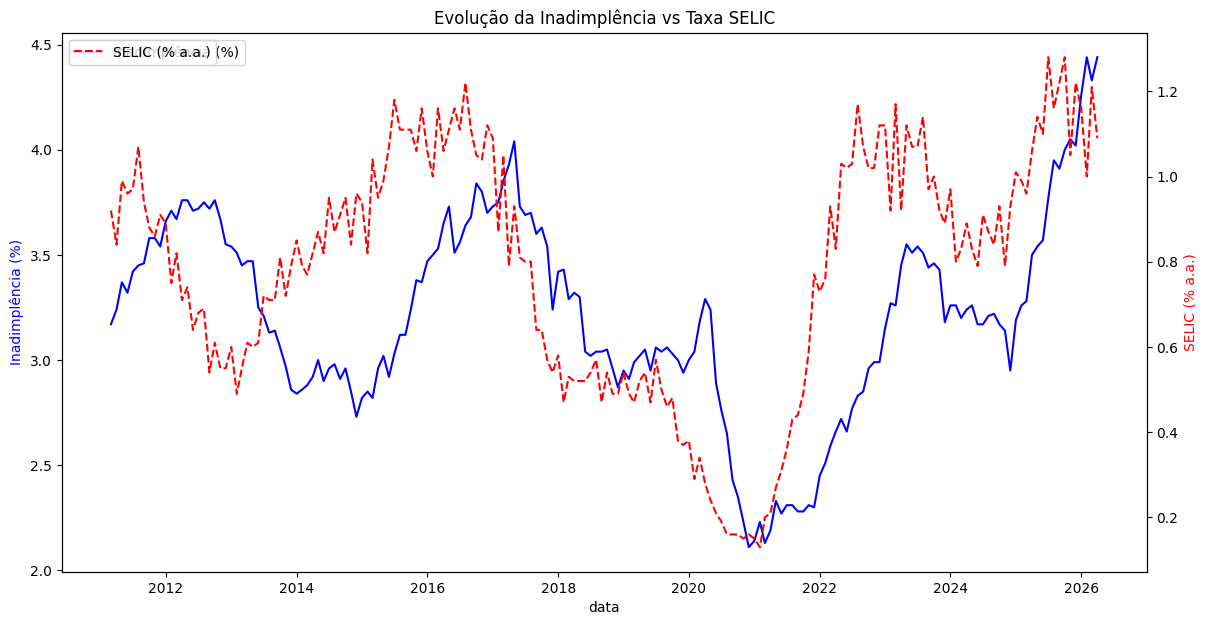

In [2]:
# Visualização das Séries Temporais
if 'df_temporal' in locals() and not df_temporal.empty:
    fig, ax1 = plt.subplots(figsize=(14, 7))
    sns.lineplot(data=df_temporal, x=df_temporal.index, y='Inadimplencia', ax=ax1, color='blue', label='Inadimplência (%)')
    ax1.set_ylabel('Inadimplência (%)', color='blue')

    if 'SELIC' in df_temporal.columns:
        ax2 = ax1.twinx()
        sns.lineplot(data=df_temporal, x=df_temporal.index, y='SELIC', ax=ax2, color='red', label='SELIC (% a.a.)', linestyle='--')
        ax2.set_ylabel('SELIC (% a.a.)', color='red')
        plt.title('Evolução da Inadimplência vs Taxa SELIC')
    else:
        plt.title('Evolução da Inadimplência (SELIC indisponível)')

    plt.show()
else:
    print('Dados não disponíveis para plotagem.')

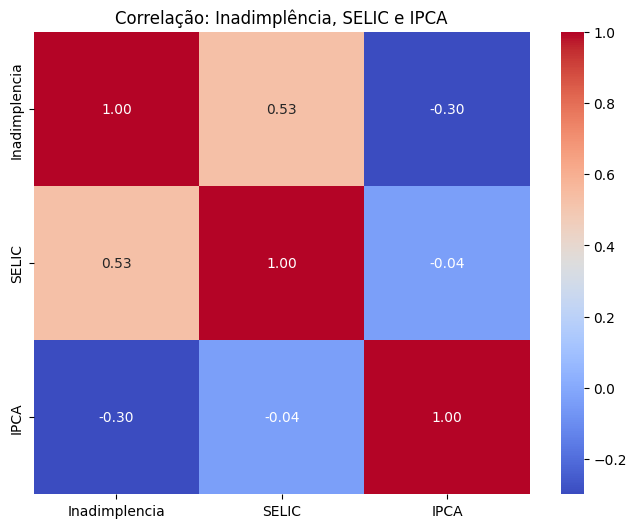

In [3]:
# Matriz de Correlação
if 'df_temporal' in locals() and not df_temporal.empty:
    plt.figure(figsize=(8, 6))
    corr_matrix = df_temporal.corr()
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlação: Inadimplência, SELIC e IPCA')
    plt.show()
else:
    print('Dados não disponíveis para correlação.')